In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
model = joblib.load("../models/loan_model.pkl")

X_test = pd.read_csv("../datasets/X_test.csv")

y_test = pd.read_csv("../datasets/y_test.csv").values.ravel()

print("Model and Dataset Loaded Successfully")

Model and Dataset Loaded Successfully


In [3]:
y_pred = model.predict(X_test)

print("Predictions Completed")

Predictions Completed


In [4]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", round(accuracy * 100, 2), "%")

Model Accuracy : 84.55 %


In [5]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.88      0.58      0.70        38
           1       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123



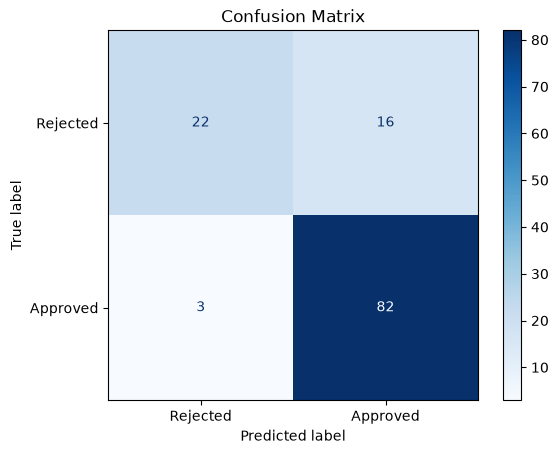

In [6]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [7]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy"
    ],

    "Value":[
        round(accuracy * 100,2)
    ]

})

metrics.to_csv(
    "../models/evaluation_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,Accuracy,84.55


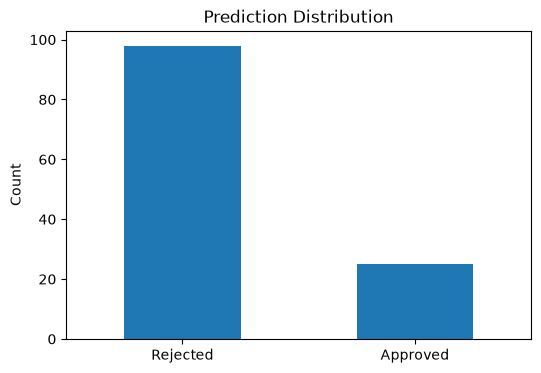

In [8]:
plt.figure(figsize=(6,4))

pd.Series(y_pred).value_counts().plot(
    kind="bar"
)

plt.xticks(
    [0,1],
    ["Rejected","Approved"],
    rotation=0
)

plt.title("Prediction Distribution")

plt.ylabel("Count")

plt.show()

# Feature Importance

The deployed model is **K-Nearest Neighbors (KNN)**.

Unlike Decision Tree, Random Forest, and XGBoost, KNN is a distance-based algorithm and does not calculate feature importance scores.

Prediction is based on similarity between applicants in the feature space rather than weighted feature contributions.

# Model Evaluation Summary

Best Model : K-Nearest Neighbors

Testing Accuracy : 84.55 %

Advantages

- Good Generalization
- Highest Testing Accuracy
- Low Overfitting
- Fast Prediction

This model has been deployed in the Flask web application for real-time loan eligibility prediction.